# Experiment 1.3.7 — Complementary temporal feature fusion

## Scientific question

Experiments 1.3.5–1.3.6 showed that the frozen SNN representation is not consistently better than direct 250 ms input counts when used alone. This experiment asks a different question:

\[
\boxed{\text{Does the frozen SNN contain complementary temporal information that is absent from the robust raw-count representation?}}
\]

The SNN backbone is **never retrained**. We reuse the completed Experiment 1.3.5 checkpoints (`seed 11 / 23 / 101`) and compare:

- `Raw250`: 250 ms raw-input channel counts;
- `SNN250`: frozen L3 250 ms spike counts;
- `SNN125`: frozen L3 125 ms spike counts;
- `Raw250 + SNN250`;
- `Raw250 + SNN125`.

Two controls are added:

1. **Validation-selected regularization:** Logistic Regression `C` is selected only from validation balanced accuracy. Test is evaluated only after selection.
2. **Dimension control:** each branch is independently standardized and PCA-compressed to at most 256 dimensions using train data only.
3. **Shuffled-SNN control:** the SNN branch is permuted across samples before fusion, preserving dimensionality/distribution while destroying sample-specific correspondence.

A positive fusion gain, especially after PCA control and relative to shuffled-SNN fusion, supports the interpretation that the SNN provides complementary temporal information rather than merely extra feature dimensions.

In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import math
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import snntorch as snn
from snntorch import surrogate

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

DATASET_ROOTS = [
    REPO_ROOT / 'outputs/action0_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded',
    REPO_ROOT / 'outputs/action1_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded',
]

EXPECTED_EVENT_REPRESENTATION = 'unsigned'
EXPECTED_EVENT_FEATURE_SCHEMA = 'custom_wavelet_polarity_split_abs_events_v1'
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = 36
EXPECTED_FS = 64.0
INCLUDED_LABELS = ('A','B','C','D','E','X','G','H','I','J','K','L')

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
SNN_SEEDS = (11, 23, 101)
COARSE_BIN_MS = 250.0
TEMPORAL_BIN_SAMPLES = {'SNN250': 16, 'SNN125': 8}

SURROGATE_SLOPE = 25.0
RESET_MECHANISM = 'subtract'
BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LOGREG_C_GRID = (1e-3, 1e-2, 1e-1, 1.0, 10.0)
LOGREG_MAX_ITER = 5000
PCA_TARGET_DIM = 256
N_SHUFFLES = 20
CACHE_FEATURES = True

SOURCE_EXPERIMENT_ID = 'experiment_1_3_5_continuous_snn_local_features'
SOURCE_RESULTS_DIR = REPO_ROOT / 'notebooks/artifacts' / SOURCE_EXPERIMENT_ID
EXPERIMENT_ID = 'experiment_1_3_7_complementary_temporal_feature_fusion'
RESULTS_DIR = REPO_ROOT / 'notebooks/artifacts' / EXPERIMENT_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def derive_seed(master_seed: int, *parts: object) -> int:
    text = '|'.join([str(master_seed), *(str(p) for p in parts)])
    return int.from_bytes(hashlib.sha256(text.encode()).digest()[:4], 'little')


print('Repository root:', REPO_ROOT)
print('Device:', DEVICE)
print('Source checkpoints:', SOURCE_RESULTS_DIR)
print('Output directory:', RESULTS_DIR)
print('C grid:', LOGREG_C_GRID)


Repository root: /home/ted/project/writingRing
Device: cuda
Source checkpoints: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_5_continuous_snn_local_features
Output directory: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_7_complementary_temporal_feature_fusion
C grid: (0.001, 0.01, 0.1, 1.0, 10.0)


## 1. Load the same cohort and reconstruct the fixed split

This duplicates the Experiment 1.3.5/1.3.6 cohort protocol so that all features and labels are reconstructed from the same source data and the same user-disjoint split.

In [2]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

fs_values = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(fs_values) != 1:
    raise ValueError(f'Expected one shared sampling rate, got {fs_values}')
SAMPLING_RATE_HZ = fs_values.pop()
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_FS):
    raise ValueError((SAMPLING_RATE_HZ, EXPECTED_FS))

for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = metadata.raw
    if raw.get('event_representation') != EXPECTED_EVENT_REPRESENTATION:
        raise ValueError(f'{root}: unexpected event representation')
    if raw.get('event_feature_schema') != EXPECTED_EVENT_FEATURE_SCHEMA:
        raise ValueError(f'{root}: unexpected event feature schema')
    if raw.get('event_channel_count') != EVENT_CHANNEL_COUNT:
        raise ValueError(f'{root}: expected {EVENT_CHANNEL_COUNT} event channels')
    if metadata.channel_count != TOTAL_CHANNEL_COUNT:
        raise ValueError(f'{root}: expected {TOTAL_CHANNEL_COUNT} total channels')

rows = []
keep = set(INCLUDED_LABELS)
for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        if label not in keep:
            continue
        rows.append({
            'package_index': package_index,
            'segment_index': segment_index,
            'user': str(package.user),
            'action': str(package.action),
            'label': str(label),
            'valid_length': int(package.valid_lengths[segment_index]),
            'package_padded_length': int(package.padded_spike_imu.shape[1]),
            'sample_id': f'{package.user}/action_{package.action}/{segment_index}',
        })

manifest = pd.DataFrame(rows)
labels_sorted = sorted(manifest.label.unique().tolist())
CLASS_TO_IDX = {lab: i for i, lab in enumerate(labels_sorted)}
manifest['label_idx'] = manifest.label.map(CLASS_TO_IDX).astype(int)
N_CLASSES = len(labels_sorted)
GLOBAL_PADDED_LENGTH = int(manifest.package_padded_length.max())
COARSE_BIN_SAMPLES = int(np.rint(COARSE_BIN_MS * SAMPLING_RATE_HZ / 1000.0))
N_COARSE_BINS = int(math.ceil(GLOBAL_PADDED_LENGTH / COARSE_BIN_SAMPLES))
PADDED_LENGTH = N_COARSE_BINS * COARSE_BIN_SAMPLES

if COARSE_BIN_SAMPLES != 16 or PADDED_LENGTH != 256:
    raise ValueError((COARSE_BIN_SAMPLES, PADDED_LENGTH))


def make_user_split(split_seed: int):
    users = np.asarray(sorted(manifest.user.unique()), dtype=object)
    rng = np.random.default_rng(derive_seed(split_seed, 'user_split'))
    rng.shuffle(users)
    n_train = int(round(TRAIN_FRACTION * len(users)))
    n_val = int(round(VAL_FRACTION * len(users)))
    train_users = set(users[:n_train])
    val_users = set(users[n_train:n_train+n_val])
    test_users = set(users[n_train+n_val:])
    part = lambda us: manifest[manifest.user.isin(us)].reset_index(drop=True)
    return part(train_users), part(val_users), part(test_users), {
        'train_users': tuple(sorted(train_users)),
        'val_users': tuple(sorted(val_users)),
        'test_users': tuple(sorted(test_users)),
    }


def build_events(df: pd.DataFrame) -> np.ndarray:
    out = np.zeros((len(df), PADDED_LENGTH, EVENT_CHANNEL_COUNT), dtype=np.float32)
    for i, row in enumerate(df.itertuples(index=False)):
        package = data.packages[int(row.package_index)]
        x = np.asarray(
            package.padded_spike_imu[int(row.segment_index), :, :EVENT_CHANNEL_COUNT],
            dtype=np.float32,
        )
        n = min(len(x), PADDED_LENGTH)
        out[i, :n] = x[:n]
    return out


train_df, val_df, test_df, split_info = make_user_split(SPLIT_SEED)
X_train, X_val, X_test = map(build_events, (train_df, val_df, test_df))
y_train = train_df.label_idx.to_numpy(np.int64)
y_val = val_df.label_idx.to_numpy(np.int64)
y_test = test_df.label_idx.to_numpy(np.int64)

print('train:', X_train.shape, 'users=', train_df.user.nunique())
print('val:  ', X_val.shape, 'users=', val_df.user.nunique())
print('test: ', X_test.shape, 'users=', test_df.user.nunique())
print('users:', split_info)


train: (632, 256, 30) users= 14
val:   (126, 256, 30) users= 3
test:  (95, 256, 30) users= 3
users: {'train_users': ('user_0', 'user_1', 'user_11', 'user_12', 'user_14', 'user_19', 'user_2', 'user_3', 'user_4', 'user_5', 'user_6', 'user_7', 'user_8', 'user_9'), 'val_users': ('user_15', 'user_16', 'user_20'), 'test_users': ('user_10', 'user_13', 'user_18')}


## 2. Restore the exact frozen Experiment 1.3.5 backbone

The checkpoint configuration is the source of truth. The completed run used widths `(128, 128, 64)` and shifts `((2,3), (2,3), (2,))`.

In [3]:
def shift_to_alpha(shift: int) -> float:
    return float(1.0 - 2.0 ** (-int(shift)))


def allocate_neurons(width: int, shifts: tuple[int, ...]) -> tuple[int, ...]:
    base, remainder = divmod(width, len(shifts))
    counts = [base] * len(shifts)
    order = []
    left, right = 0, len(shifts) - 1
    while left <= right:
        order.append(left)
        if left != right:
            order.append(right)
        left += 1
        right -= 1
    for i in range(remainder):
        counts[order[i]] += 1
    return tuple(counts)


def build_alpha_tensor(width: int, shifts: tuple[int, ...]) -> torch.Tensor:
    values = []
    for shift, count in zip(shifts, allocate_neurons(width, shifts), strict=True):
        values.extend([shift_to_alpha(shift)] * count)
    return torch.tensor(values, dtype=torch.float32)


def checkpoint_path(seed: int) -> Path:
    return SOURCE_RESULTS_DIR / f'snn_seed_{seed}.pt'


def canonical_config(payload: dict) -> dict:
    cfg = payload.get('config')
    required = ('experiment_id','fs','bin_samples','widths','shifts','tau_mem_ms','threshold','split_seed')
    if cfg is None or any(k not in cfg for k in required):
        raise ValueError(f'Unexpected checkpoint config: {cfg}')
    return {
        'experiment_id': str(cfg['experiment_id']),
        'fs': float(cfg['fs']),
        'bin_samples': int(cfg['bin_samples']),
        'widths': tuple(int(v) for v in cfg['widths']),
        'shifts': tuple(tuple(int(s) for s in layer) for layer in cfg['shifts']),
        'tau_mem_ms': float(cfg['tau_mem_ms']),
        'threshold': float(cfg['threshold']),
        'split_seed': int(cfg['split_seed']),
    }


reference_payload = torch.load(checkpoint_path(SNN_SEEDS[0]), map_location='cpu', weights_only=False)
REFERENCE_CONFIG = canonical_config(reference_payload)
if REFERENCE_CONFIG['experiment_id'] != SOURCE_EXPERIMENT_ID:
    raise ValueError(REFERENCE_CONFIG)
if not np.isclose(REFERENCE_CONFIG['fs'], SAMPLING_RATE_HZ):
    raise ValueError('Sampling-rate mismatch')
if REFERENCE_CONFIG['bin_samples'] != COARSE_BIN_SAMPLES:
    raise ValueError('Readout-bin mismatch')
if REFERENCE_CONFIG['split_seed'] != SPLIT_SEED:
    raise ValueError('Split-seed mismatch')

SNN_LAYER_WIDTHS = REFERENCE_CONFIG['widths']
SNN_LAYER_SHIFTS = REFERENCE_CONFIG['shifts']
TAU_MEM_MS = REFERENCE_CONFIG['tau_mem_ms']
THRESHOLD = REFERENCE_CONFIG['threshold']
BETA = float(math.exp(-(1000.0 / SAMPLING_RATE_HZ) / TAU_MEM_MS))


class ContinuousLocalFeatureSNN(nn.Module):
    def __init__(self):
        super().__init__()
        h1, h2, d = SNN_LAYER_WIDTHS
        grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)
        self.fc1 = nn.Linear(EVENT_CHANNEL_COUNT, h1, bias=False)
        self.lif1 = snn.Synaptic(alpha=build_alpha_tensor(h1, SNN_LAYER_SHIFTS[0]), beta=BETA, threshold=THRESHOLD, spike_grad=grad, reset_mechanism=RESET_MECHANISM)
        self.fc2 = nn.Linear(h1, h2, bias=False)
        self.lif2 = snn.Synaptic(alpha=build_alpha_tensor(h2, SNN_LAYER_SHIFTS[1]), beta=BETA, threshold=THRESHOLD, spike_grad=grad, reset_mechanism=RESET_MECHANISM)
        self.fc3 = nn.Linear(h2, d, bias=False)
        self.lif3 = snn.Synaptic(alpha=build_alpha_tensor(d, SNN_LAYER_SHIFTS[2]), beta=BETA, threshold=THRESHOLD, spike_grad=grad, reset_mechanism=RESET_MECHANISM)
        self.classifier = nn.Linear(N_COARSE_BINS * d, N_CLASSES, bias=True)


def load_frozen_checkpoint(seed: int):
    payload = torch.load(checkpoint_path(seed), map_location='cpu', weights_only=False)
    got = canonical_config(payload)
    if got != REFERENCE_CONFIG:
        raise ValueError(f'Checkpoint config mismatch for seed {seed}')
    model = ContinuousLocalFeatureSNN()
    model.load_state_dict(payload['model_state_dict'], strict=True)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    return model, payload


source_results = pd.read_csv(SOURCE_RESULTS_DIR / 'results.csv')
for seed in SNN_SEEDS:
    _, payload = load_frozen_checkpoint(seed)
    csv_row = source_results[(source_results.model == 'continuous_snn_plus_linear') & (source_results.seed == float(seed))].iloc[0]
    if not np.isclose(payload['test']['balanced_accuracy'], csv_row.test_balanced_accuracy):
        raise ValueError(f'Checkpoint/results.csv mismatch for seed {seed}')

print('Frozen widths:', SNN_LAYER_WIDTHS)
print('Frozen shifts:', SNN_LAYER_SHIFTS)
display(source_results)


Frozen widths: (128, 128, 64)
Frozen shifts: ((2, 3), (2, 3), (2,))


,model,seed,best_epoch,train_accuracy,train_balanced_accuracy,train_macro_f1,val_accuracy,val_balanced_accuracy,val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1
0,count_250ms_plus_linear,NaN,NaN,1.000000,1.000000,1.000000,0.714286,0.707705,0.706672,0.547368,0.556217,0.548821
1,continuous_snn_plus_linear,11.0,94.0,0.985759,0.986360,0.986664,0.634921,0.626819,0.622948,0.473684,0.477017,0.461864
2,continuous_snn_plus_linear,23.0,86.0,0.987342,0.987741,0.988166,0.626984,0.641567,0.616386,0.452632,0.481481,0.451740
3,continuous_snn_plus_linear,101.0,80.0,0.968354,0.969616,0.969428,0.658730,0.657937,0.643929,0.431579,0.451389,0.435343


## 3. Extract only the frozen L3 readouts needed by 1.3.7

The SNN runs continuously over all 256 samples. We accumulate L3 spikes into 250 ms (16-sample) and 125 ms (8-sample) non-overlapping readout bins. Optional `.npz` caching makes later probe reruns much faster.

In [4]:
@torch.no_grad()
def extract_l3_readouts(model: ContinuousLocalFeatureSNN, X: np.ndarray) -> dict[str, np.ndarray]:
    model = model.to(DEVICE)
    model.eval()
    h1, h2, d = SNN_LAYER_WIDTHS
    out250, out125 = [], []

    loader = DataLoader(
        TensorDataset(torch.from_numpy(X)),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    for (xb,) in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        B, T, _ = xb.shape
        syn1 = torch.zeros(B, h1, device=DEVICE); mem1 = torch.zeros_like(syn1)
        syn2 = torch.zeros(B, h2, device=DEVICE); mem2 = torch.zeros_like(syn2)
        syn3 = torch.zeros(B, d, device=DEVICE); mem3 = torch.zeros_like(syn3)
        acc250 = torch.zeros(B, d, device=DEVICE)
        acc125 = torch.zeros(B, d, device=DEVICE)
        f250, f125 = [], []

        for t in range(T):
            s1, syn1, mem1 = model.lif1(model.fc1(xb[:, t]), syn1, mem1)
            s2, syn2, mem2 = model.lif2(model.fc2(s1), syn2, mem2)
            s3, syn3, mem3 = model.lif3(model.fc3(s2), syn3, mem3)
            acc250 += s3
            acc125 += s3
            if (t + 1) % 8 == 0:
                f125.append(acc125.clone())
                acc125.zero_()
            if (t + 1) % 16 == 0:
                f250.append(acc250.clone())
                acc250.zero_()

        out250.append(torch.stack(f250, dim=1).cpu().numpy().astype(np.float32))
        out125.append(torch.stack(f125, dim=1).cpu().numpy().astype(np.float32))

    return {
        'SNN250': np.concatenate(out250, axis=0),
        'SNN125': np.concatenate(out125, axis=0),
    }


def load_or_extract_seed_features(seed: int):
    cache = RESULTS_DIR / f'frozen_l3_seed_{seed}.npz'
    if CACHE_FEATURES and cache.exists():
        z = np.load(cache)
        print(f'Loaded cached features: {cache.name}')
        return {split: {rep: z[f'{split}_{rep}'] for rep in ('SNN250','SNN125')} for split in ('train','val','test')}

    model, _ = load_frozen_checkpoint(seed)
    print(f'Extracting frozen seed {seed} train...')
    tr = extract_l3_readouts(model, X_train)
    print(f'Extracting frozen seed {seed} val...')
    va = extract_l3_readouts(model, X_val)
    print(f'Extracting frozen seed {seed} test...')
    te = extract_l3_readouts(model, X_test)
    result = {'train': tr, 'val': va, 'test': te}

    if CACHE_FEATURES:
        np.savez_compressed(
            cache,
            **{f'{split}_{rep}': result[split][rep] for split in ('train','val','test') for rep in ('SNN250','SNN125')}
        )
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


def count_over_samples(X: np.ndarray, samples_per_bin: int) -> np.ndarray:
    N, T, D = X.shape
    if T % samples_per_bin != 0:
        raise ValueError((T, samples_per_bin))
    return X.reshape(N, T // samples_per_bin, samples_per_bin, D).sum(axis=2)


RAW = {
    'train': count_over_samples(X_train, COARSE_BIN_SAMPLES),
    'val': count_over_samples(X_val, COARSE_BIN_SAMPLES),
    'test': count_over_samples(X_test, COARSE_BIN_SAMPLES),
}

print('Raw250:', RAW['train'].shape, 'dim=', int(np.prod(RAW['train'].shape[1:])))


Raw250: (632, 16, 30) dim= 480


## 4. Probe protocol: train-only preprocessing and validation-selected `C`

For every representation, `StandardScaler` is fit on train only. Five Logistic Regression regularization values are trained on train and scored on validation. The first `C` reaching the best validation balanced accuracy is selected, so ties favor stronger regularization because the grid is ordered from small to large. Only the selected model is evaluated on test.

In [5]:
def flatten_features(F: np.ndarray) -> np.ndarray:
    return np.asarray(F, dtype=np.float32).reshape(len(F), -1)


def classification_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
    }


def select_c_and_evaluate(F_train, F_val, F_test, seed_tag: object):
    A = flatten_features(F_train)
    B = flatten_features(F_val)
    Ctest = flatten_features(F_test)

    scaler = StandardScaler()
    A = scaler.fit_transform(A)
    B = scaler.transform(B)
    Ctest = scaler.transform(Ctest)

    sweep = []
    best = None
    for C_value in LOGREG_C_GRID:
        clf = LogisticRegression(
            max_iter=LOGREG_MAX_ITER,
            solver='lbfgs',
            C=C_value,
            random_state=derive_seed(SPLIT_SEED, 'probe', seed_tag, C_value),
        )
        clf.fit(A, y_train)
        val_pred = clf.predict(B)
        val_metrics = classification_metrics(y_val, val_pred)
        sweep.append({'C': C_value, **val_metrics})
        if best is None or val_metrics['balanced_accuracy'] > best['val']['balanced_accuracy'] + 1e-12:
            best = {'C': C_value, 'model': clf, 'val': val_metrics}

    train_metrics = classification_metrics(y_train, best['model'].predict(A))
    test_metrics = classification_metrics(y_test, best['model'].predict(Ctest))
    return {
        'feature_dim': int(A.shape[1]),
        'selected_C': float(best['C']),
        'train': train_metrics,
        'val': best['val'],
        'test': test_metrics,
        'c_sweep': pd.DataFrame(sweep),
    }


def fit_branch_pca(F_train, F_val, F_test, tag: object):
    A = flatten_features(F_train)
    B = flatten_features(F_val)
    C = flatten_features(F_test)
    scaler = StandardScaler()
    A = scaler.fit_transform(A)
    B = scaler.transform(B)
    C = scaler.transform(C)
    n_components = min(PCA_TARGET_DIM, A.shape[1], A.shape[0] - 1)
    pca = PCA(
        n_components=n_components,
        svd_solver='randomized',
        random_state=derive_seed(SPLIT_SEED, 'pca', tag),
    )
    return pca.fit_transform(A).astype(np.float32), pca.transform(B).astype(np.float32), pca.transform(C).astype(np.float32), n_components


def concat_features(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return np.concatenate([flatten_features(A), flatten_features(B)], axis=1).astype(np.float32)


## 5. Native-dimension complementary fusion

This is the primary diagnostic. It compares each frozen SNN representation alone against fusion with the robust raw-count branch, while selecting Logistic Regression regularization separately for each representation.

In [6]:
all_rows = []
c_sweep_rows = []
seed_features = {}

raw_result = select_c_and_evaluate(RAW['train'], RAW['val'], RAW['test'], seed_tag=('native','Raw250'))
RAW_TEST_BA = raw_result['test']['balanced_accuracy']
all_rows.append({
    'protocol': 'native', 'representation': 'Raw250', 'snn_seed': np.nan,
    'feature_dim': raw_result['feature_dim'], 'selected_C': raw_result['selected_C'],
    'train_BA': raw_result['train']['balanced_accuracy'], 'val_BA': raw_result['val']['balanced_accuracy'],
    'test_accuracy': raw_result['test']['accuracy'], 'test_BA': raw_result['test']['balanced_accuracy'],
    'test_macro_f1': raw_result['test']['macro_f1'], 'delta_test_BA_vs_Raw': 0.0,
})
for row in raw_result['c_sweep'].to_dict('records'):
    c_sweep_rows.append({'protocol':'native','representation':'Raw250','snn_seed':np.nan,**row})

for seed in SNN_SEEDS:
    print('=' * 90)
    print('Frozen SNN seed:', seed)
    feats = load_or_extract_seed_features(seed)
    seed_features[seed] = feats

    specs = {
        'SNN250': (feats['train']['SNN250'], feats['val']['SNN250'], feats['test']['SNN250']),
        'SNN125': (feats['train']['SNN125'], feats['val']['SNN125'], feats['test']['SNN125']),
        'Raw250+SNN250': (
            concat_features(RAW['train'], feats['train']['SNN250']),
            concat_features(RAW['val'], feats['val']['SNN250']),
            concat_features(RAW['test'], feats['test']['SNN250']),
        ),
        'Raw250+SNN125': (
            concat_features(RAW['train'], feats['train']['SNN125']),
            concat_features(RAW['val'], feats['val']['SNN125']),
            concat_features(RAW['test'], feats['test']['SNN125']),
        ),
    }

    for rep_name, (Ftr, Fva, Fte) in specs.items():
        result = select_c_and_evaluate(Ftr, Fva, Fte, seed_tag=('native', seed, rep_name))
        all_rows.append({
            'protocol': 'native', 'representation': rep_name, 'snn_seed': seed,
            'feature_dim': result['feature_dim'], 'selected_C': result['selected_C'],
            'train_BA': result['train']['balanced_accuracy'], 'val_BA': result['val']['balanced_accuracy'],
            'test_accuracy': result['test']['accuracy'], 'test_BA': result['test']['balanced_accuracy'],
            'test_macro_f1': result['test']['macro_f1'],
            'delta_test_BA_vs_Raw': result['test']['balanced_accuracy'] - RAW_TEST_BA,
        })
        for row in result['c_sweep'].to_dict('records'):
            c_sweep_rows.append({'protocol':'native','representation':rep_name,'snn_seed':seed,**row})

native_df = pd.DataFrame([r for r in all_rows if r['protocol'] == 'native'])
display(native_df)


Frozen SNN seed: 11
Extracting frozen seed 11 train...
Extracting frozen seed 11 val...
Extracting frozen seed 11 test...
Frozen SNN seed: 23
Extracting frozen seed 23 train...
Extracting frozen seed 23 val...
Extracting frozen seed 23 test...
Frozen SNN seed: 101
Extracting frozen seed 101 train...
Extracting frozen seed 101 val...
Extracting frozen seed 101 test...


,protocol,representation,snn_seed,feature_dim,selected_C,train_BA,val_BA,test_accuracy,test_BA,test_macro_f1,delta_test_BA_vs_Raw
0,native,Raw250,NaN,480,0.100,0.996851,0.713261,0.536842,0.546958,0.541218,0.000000
1,native,SNN250,11.0,1024,0.100,0.983313,0.593353,0.452632,0.442295,0.422244,-0.104663
2,native,SNN125,11.0,2048,0.010,0.958966,0.605853,0.505263,0.491237,0.474937,-0.055721
3,native,Raw250+SNN250,11.0,1504,0.010,0.987299,0.687566,0.568421,0.566799,0.546097,0.019841
4,native,Raw250+SNN125,11.0,2528,0.010,0.993074,0.666733,0.536842,0.539021,0.519168,-0.007937
5,native,SNN250,23.0,1024,0.010,0.945912,0.636376,0.557895,0.586640,0.540322,0.039683
6,native,SNN125,23.0,2048,0.010,0.965775,0.676190,0.578947,0.603671,0.567759,0.056713
7,native,Raw250+SNN250,23.0,1504,0.010,0.990251,0.695866,0.621053,0.643353,0.615823,0.096396
8,native,Raw250+SNN125,23.0,2528,0.100,1.000000,0.694577,0.568421,0.597388,0.554085,0.050430
9,native,SNN250,101.0,1024,0.001,0.786193,0.610384,0.526316,0.513889,0.497787,-0.033069


## 6. PCA-256 branch-controlled fusion

Each branch is standardized and PCA-compressed independently using train data only. The standalone representations are 256-D; fusion concatenates two independently compressed 256-D branches into 512-D. This reduces the dimensionality confound from native 480/1024/2048/1504/2528-D representations.

In [7]:
raw_pca_tr, raw_pca_va, raw_pca_te, raw_pca_dim = fit_branch_pca(
    RAW['train'], RAW['val'], RAW['test'], tag='Raw250'
)
raw_pca_result = select_c_and_evaluate(raw_pca_tr, raw_pca_va, raw_pca_te, seed_tag=('pca','Raw250'))
RAW_PCA_TEST_BA = raw_pca_result['test']['balanced_accuracy']
all_rows.append({
    'protocol': 'pca256', 'representation': 'Raw250', 'snn_seed': np.nan,
    'feature_dim': raw_pca_result['feature_dim'], 'selected_C': raw_pca_result['selected_C'],
    'train_BA': raw_pca_result['train']['balanced_accuracy'], 'val_BA': raw_pca_result['val']['balanced_accuracy'],
    'test_accuracy': raw_pca_result['test']['accuracy'], 'test_BA': raw_pca_result['test']['balanced_accuracy'],
    'test_macro_f1': raw_pca_result['test']['macro_f1'], 'delta_test_BA_vs_Raw': 0.0,
})
for row in raw_pca_result['c_sweep'].to_dict('records'):
    c_sweep_rows.append({'protocol':'pca256','representation':'Raw250','snn_seed':np.nan,**row})

for seed in SNN_SEEDS:
    feats = seed_features[seed]
    for snn_name in ('SNN250', 'SNN125'):
        s_tr, s_va, s_te, s_dim = fit_branch_pca(
            feats['train'][snn_name], feats['val'][snn_name], feats['test'][snn_name], tag=(seed, snn_name)
        )

        standalone = select_c_and_evaluate(s_tr, s_va, s_te, seed_tag=('pca',seed,snn_name))
        all_rows.append({
            'protocol': 'pca256', 'representation': snn_name, 'snn_seed': seed,
            'feature_dim': standalone['feature_dim'], 'selected_C': standalone['selected_C'],
            'train_BA': standalone['train']['balanced_accuracy'], 'val_BA': standalone['val']['balanced_accuracy'],
            'test_accuracy': standalone['test']['accuracy'], 'test_BA': standalone['test']['balanced_accuracy'],
            'test_macro_f1': standalone['test']['macro_f1'],
            'delta_test_BA_vs_Raw': standalone['test']['balanced_accuracy'] - RAW_PCA_TEST_BA,
        })
        for row in standalone['c_sweep'].to_dict('records'):
            c_sweep_rows.append({'protocol':'pca256','representation':snn_name,'snn_seed':seed,**row})

        fusion_name = f'Raw250+{snn_name}'
        f_tr = np.concatenate([raw_pca_tr, s_tr], axis=1)
        f_va = np.concatenate([raw_pca_va, s_va], axis=1)
        f_te = np.concatenate([raw_pca_te, s_te], axis=1)
        fusion = select_c_and_evaluate(f_tr, f_va, f_te, seed_tag=('pca',seed,fusion_name))
        all_rows.append({
            'protocol': 'pca256', 'representation': fusion_name, 'snn_seed': seed,
            'feature_dim': fusion['feature_dim'], 'selected_C': fusion['selected_C'],
            'train_BA': fusion['train']['balanced_accuracy'], 'val_BA': fusion['val']['balanced_accuracy'],
            'test_accuracy': fusion['test']['accuracy'], 'test_BA': fusion['test']['balanced_accuracy'],
            'test_macro_f1': fusion['test']['macro_f1'],
            'delta_test_BA_vs_Raw': fusion['test']['balanced_accuracy'] - RAW_PCA_TEST_BA,
        })
        for row in fusion['c_sweep'].to_dict('records'):
            c_sweep_rows.append({'protocol':'pca256','representation':fusion_name,'snn_seed':seed,**row})

pca_df = pd.DataFrame([r for r in all_rows if r['protocol'] == 'pca256'])
display(pca_df)


,protocol,representation,snn_seed,feature_dim,selected_C,train_BA,val_BA,test_accuracy,test_BA,test_macro_f1,delta_test_BA_vs_Raw
0,pca256,Raw250,NaN,256,0.01,0.967097,0.541402,0.452632,0.468254,0.449921,0.000000
1,pca256,SNN250,11.0,256,0.01,0.950508,0.567560,0.442105,0.432209,0.426422,-0.036045
2,pca256,Raw250+SNN250,11.0,512,0.01,0.992221,0.612698,0.484211,0.474868,0.454370,0.006614
3,pca256,SNN125,11.0,256,0.01,0.943025,0.553208,0.515789,0.504299,0.490622,0.036045
4,pca256,Raw250+SNN125,11.0,512,0.01,0.994536,0.625298,0.536842,0.544643,0.531236,0.076389
5,pca256,SNN250,23.0,256,0.10,0.971913,0.558135,0.431579,0.467097,0.420192,-0.001157
6,pca256,Raw250+SNN250,23.0,512,0.01,0.993736,0.619147,0.526316,0.553075,0.514644,0.084821
7,pca256,SNN125,23.0,256,0.01,0.943841,0.622156,0.505263,0.525959,0.502535,0.057705
8,pca256,Raw250+SNN125,23.0,512,0.01,0.993736,0.656647,0.568421,0.597388,0.569323,0.129134
9,pca256,SNN250,101.0,256,0.01,0.938080,0.553307,0.431579,0.430556,0.429424,-0.037698


## 7. Shuffled-SNN fusion control

For the two **native fusion** representations, the raw branch remains aligned with each sample while the SNN branch is independently permuted across samples in train, validation, and test. Each shuffle repeats the same validation-selected `C` protocol.

If real fusion is better than shuffled fusion, the gain is attributable to sample-specific SNN information rather than merely adding high-dimensional features.

In [8]:
shuffle_rows = []

for seed in SNN_SEEDS:
    feats = seed_features[seed]
    for snn_name in ('SNN250', 'SNN125'):
        fusion_name = f'Raw250+{snn_name}'
        for shuffle_index in range(N_SHUFFLES):
            shuffled = {}
            for split_name, raw_branch in (('train', RAW['train']), ('val', RAW['val']), ('test', RAW['test'])):
                snn_branch = feats[split_name][snn_name]
                rng = np.random.default_rng(derive_seed(SPLIT_SEED, 'shuffle', seed, snn_name, shuffle_index, split_name))
                perm = rng.permutation(len(snn_branch))
                shuffled[split_name] = concat_features(raw_branch, snn_branch[perm])

            result = select_c_and_evaluate(
                shuffled['train'], shuffled['val'], shuffled['test'],
                seed_tag=('shuffle', seed, snn_name, shuffle_index),
            )
            shuffle_rows.append({
                'snn_seed': seed, 'representation': fusion_name, 'shuffle_index': shuffle_index,
                'feature_dim': result['feature_dim'], 'selected_C': result['selected_C'],
                'val_BA': result['val']['balanced_accuracy'],
                'test_accuracy': result['test']['accuracy'],
                'test_BA': result['test']['balanced_accuracy'],
                'test_macro_f1': result['test']['macro_f1'],
                'delta_test_BA_vs_Raw': result['test']['balanced_accuracy'] - RAW_TEST_BA,
            })

shuffle_df = pd.DataFrame(shuffle_rows)
shuffle_summary = (
    shuffle_df.groupby(['representation','snn_seed'], as_index=False)
    .agg(
        n_shuffles=('shuffle_index','count'),
        mean_shuffle_test_BA=('test_BA','mean'),
        sd_shuffle_test_BA=('test_BA','std'),
        mean_shuffle_delta=('delta_test_BA_vs_Raw','mean'),
    )
)

real_native_fusion = native_df[native_df.representation.str.startswith('Raw250+')]
shuffle_summary = shuffle_summary.merge(
    real_native_fusion[['representation','snn_seed','test_BA','delta_test_BA_vs_Raw']].rename(
        columns={'test_BA':'real_test_BA','delta_test_BA_vs_Raw':'real_delta'}
    ),
    on=['representation','snn_seed'],
    how='left',
)
shuffle_summary['real_minus_shuffle_mean_BA'] = shuffle_summary.real_test_BA - shuffle_summary.mean_shuffle_test_BA
display(shuffle_summary)


,representation,snn_seed,n_shuffles,mean_shuffle_test_BA,sd_shuffle_test_BA,mean_shuffle_delta,real_test_BA,real_delta,real_minus_shuffle_mean_BA
0,Raw250+SNN125,11,20,0.360144,0.047598,-0.186814,0.539021,-0.007937,0.178877
1,Raw250+SNN125,23,20,0.346321,0.040861,-0.200637,0.597388,0.050430,0.251066
2,Raw250+SNN125,101,20,0.351339,0.047089,-0.195618,0.562831,0.015873,0.211491
3,Raw250+SNN250,11,20,0.392072,0.040132,-0.154886,0.566799,0.019841,0.174727
4,Raw250+SNN250,23,20,0.407697,0.052694,-0.139261,0.643353,0.096396,0.235656
5,Raw250+SNN250,101,20,0.398074,0.046924,-0.148884,0.566964,0.020007,0.168891


## 8. Summaries, plots, and saved outputs

Native summary


,representation,n_runs,mean_test_BA,sd_test_BA,mean_test_accuracy,mean_test_macro_f1,mean_delta_test_BA_vs_Raw,sd_delta_test_BA_vs_Raw,feature_dim
0,Raw250,1,0.546958,NaN,0.536842,0.541218,0.000000,NaN,480
1,SNN250,3,0.514275,0.072173,0.512281,0.486784,-0.032683,0.072173,1024
2,SNN125,3,0.536265,0.059463,0.536842,0.515695,-0.010692,0.059463,2048
3,Raw250+SNN250,3,0.592372,0.044151,0.575439,0.564642,0.045414,0.044151,1504
4,Raw250+SNN125,3,0.566413,0.029348,0.547368,0.537070,0.019455,0.029348,2528


PCA-controlled summary


,representation,n_runs,mean_test_BA,sd_test_BA,mean_test_accuracy,mean_test_macro_f1,mean_delta_test_BA_vs_Raw,sd_delta_test_BA_vs_Raw,feature_dim
0,Raw250,1,0.468254,NaN,0.452632,0.449921,0.000000,NaN,256
1,SNN250,3,0.443287,0.020636,0.435088,0.425346,-0.024967,0.020636,256
2,SNN125,3,0.504023,0.022075,0.501754,0.487232,0.035769,0.022075,256
3,Raw250+SNN250,3,0.525463,0.043878,0.515789,0.500509,0.057209,0.043878,512
4,Raw250+SNN125,3,0.559634,0.032926,0.543860,0.539959,0.091380,0.032926,512


Shuffle control


,representation,snn_seed,n_shuffles,mean_shuffle_test_BA,sd_shuffle_test_BA,mean_shuffle_delta,real_test_BA,real_delta,real_minus_shuffle_mean_BA
0,Raw250+SNN125,11,20,0.360144,0.047598,-0.186814,0.539021,-0.007937,0.178877
1,Raw250+SNN125,23,20,0.346321,0.040861,-0.200637,0.597388,0.050430,0.251066
2,Raw250+SNN125,101,20,0.351339,0.047089,-0.195618,0.562831,0.015873,0.211491
3,Raw250+SNN250,11,20,0.392072,0.040132,-0.154886,0.566799,0.019841,0.174727
4,Raw250+SNN250,23,20,0.407697,0.052694,-0.139261,0.643353,0.096396,0.235656
5,Raw250+SNN250,101,20,0.398074,0.046924,-0.148884,0.566964,0.020007,0.168891


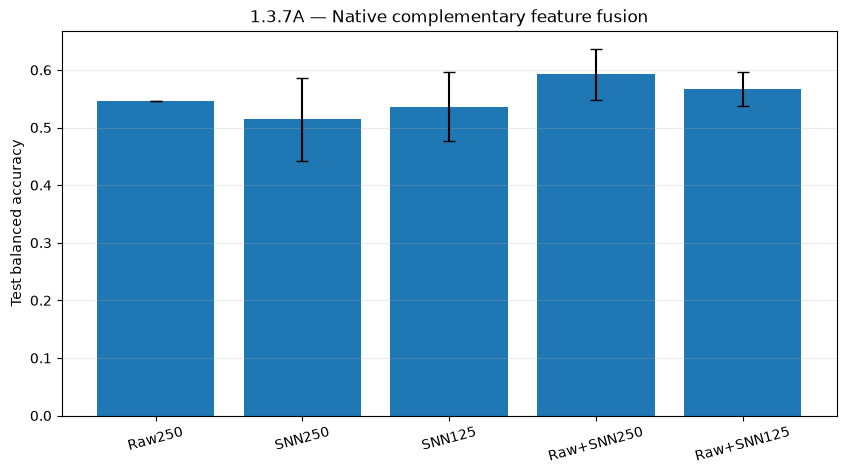

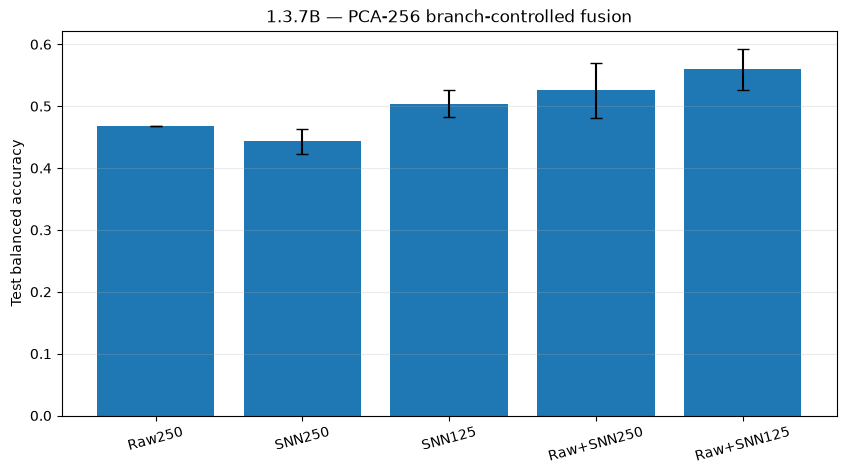

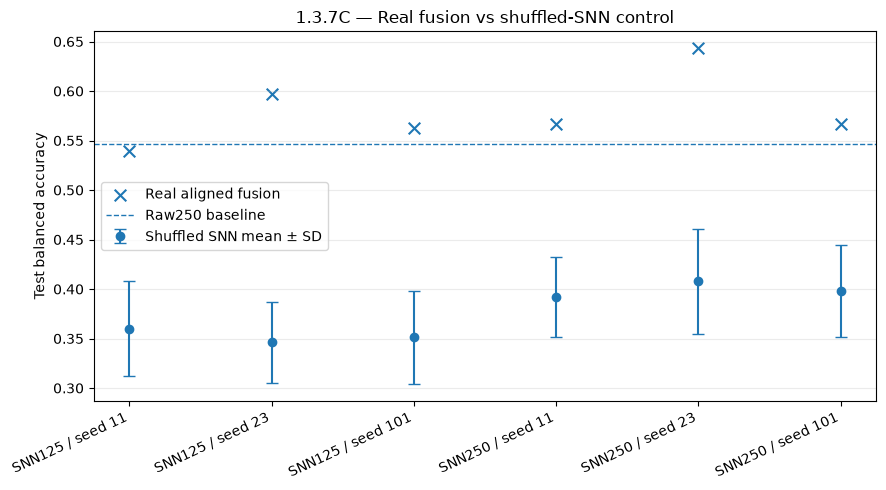

Saved Experiment 1.3.7 outputs to: /home/ted/project/writingRing/notebooks/artifacts/experiment_1_3_7_complementary_temporal_feature_fusion


In [9]:
all_results_df = pd.DataFrame(all_rows)
c_sweep_df = pd.DataFrame(c_sweep_rows)


def summarize_protocol(protocol: str) -> pd.DataFrame:
    d = all_results_df[all_results_df.protocol == protocol].copy()
    rows = []
    for rep_name in ('Raw250','SNN250','SNN125','Raw250+SNN250','Raw250+SNN125'):
        g = d[d.representation == rep_name]
        rows.append({
            'representation': rep_name,
            'n_runs': len(g),
            'mean_test_BA': g.test_BA.mean(),
            'sd_test_BA': g.test_BA.std(ddof=1) if len(g) > 1 else np.nan,
            'mean_test_accuracy': g.test_accuracy.mean(),
            'mean_test_macro_f1': g.test_macro_f1.mean(),
            'mean_delta_test_BA_vs_Raw': g.delta_test_BA_vs_Raw.mean(),
            'sd_delta_test_BA_vs_Raw': g.delta_test_BA_vs_Raw.std(ddof=1) if len(g) > 1 else np.nan,
            'feature_dim': int(g.feature_dim.iloc[0]),
        })
    return pd.DataFrame(rows)


native_summary = summarize_protocol('native')
pca_summary = summarize_protocol('pca256')

print('Native summary')
display(native_summary)
print('PCA-controlled summary')
display(pca_summary)
print('Shuffle control')
display(shuffle_summary)

for title, summary in (
    ('1.3.7A — Native complementary feature fusion', native_summary),
    ('1.3.7B — PCA-256 branch-controlled fusion', pca_summary),
):
    plt.figure(figsize=(10, 5))
    x = np.arange(len(summary))
    plt.bar(x, summary.mean_test_BA, yerr=summary.sd_test_BA.fillna(0), capsize=4)
    plt.xticks(x, ['Raw250','SNN250','SNN125','Raw+SNN250','Raw+SNN125'], rotation=15)
    plt.ylabel('Test balanced accuracy')
    plt.title(title)
    plt.grid(axis='y', alpha=0.25)
    plt.show()

plt.figure(figsize=(9, 5))
shuffle_plot = shuffle_summary.copy()
labels = [f"{r.representation.replace('Raw250+','')} / seed {int(r.snn_seed)}" for r in shuffle_plot.itertuples()]
x = np.arange(len(shuffle_plot))
plt.errorbar(x, shuffle_plot.mean_shuffle_test_BA, yerr=shuffle_plot.sd_shuffle_test_BA, fmt='o', capsize=4, label='Shuffled SNN mean ± SD')
plt.scatter(x, shuffle_plot.real_test_BA, marker='x', s=70, label='Real aligned fusion')
plt.axhline(RAW_TEST_BA, linestyle='--', linewidth=1, label='Raw250 baseline')
plt.xticks(x, labels, rotation=25, ha='right')
plt.ylabel('Test balanced accuracy')
plt.title('1.3.7C — Real fusion vs shuffled-SNN control')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

all_results_df.to_csv(RESULTS_DIR / 'all_results.csv', index=False)
native_summary.to_csv(RESULTS_DIR / 'native_summary.csv', index=False)
pca_summary.to_csv(RESULTS_DIR / 'pca_summary.csv', index=False)
shuffle_df.to_csv(RESULTS_DIR / 'shuffle_control.csv', index=False)
shuffle_summary.to_csv(RESULTS_DIR / 'shuffle_summary.csv', index=False)
c_sweep_df.to_csv(RESULTS_DIR / 'c_selection_sweeps.csv', index=False)

print('Saved Experiment 1.3.7 outputs to:', RESULTS_DIR)


## 9. Interpretation rules

The primary quantities are the fusion gain

\[
\Delta BA = BA_{Raw+SNN} - BA_{Raw}
\]

and the gap between aligned and shuffled fusion.

### Case A — Fusion improves in native and PCA-controlled protocols

If `Raw+SNN > Raw` consistently across seeds and the gain survives PCA control, the SNN contains complementary temporal information. The natural next architecture is a robust count branch plus an SNN temporal-residual branch rather than replacing count features.

### Case B — Native fusion improves, PCA-controlled fusion does not

Treat the native gain cautiously. It may depend on high-dimensional capacity or weak regularization rather than a compact complementary structure.

### Case C — Aligned fusion beats shuffled fusion

This supports a sample-specific complementary-information interpretation. If aligned and shuffled fusion are similar, improvement from adding the SNN branch is not strong evidence of useful SNN temporal information.

### Case D — Fusion is no better than Raw250

Then the current frozen SNN representation adds little incremental information beyond robust coarse counts. The next step should change how the SNN is trained or how the first transformation is constrained, rather than adding SNN capacity.